# Datos de ALeRCE: objetos astronómicos etiquetados

**Contexto.** ALeRCE es un broker astronómico chileno que clasifica en tiempo real las alertas del telescopio Zwicky Transient Facility (ZTF). Cada noche llegan cientos de miles de alertas, un flujo continuo de datos donde el aprendizaje en línea tiene sentido natural.

**Datos.** Conjunto etiquetado del clasificador de curvas de luz de ALeRCE, publicado por Sánchez-Sáez y otros (2021, The Astronomical Journal 161, 141) en Zenodo con licencia CC BY 4.0. Tiene 123.496 objetos, 15 clases y 183 características calculadas de sus curvas de luz.

**Qué hace este notebook.** Describe los datos, la jerarquía de clases y los valores faltantes, y explica las decisiones de preparación que usa el notebook 02.

**Resultado principal.** Las clases están muy desbalanceadas: 70,5% de los objetos son periódicos, 28,1% estocásticos y solo 1,4% transitorios. El 30% de los objetos tiene algún valor faltante, pero entre los transitorios la cifra sube a 88%. Eliminar las filas incompletas, como hacía la tesis original, habría borrado casi toda la clase más rara. Por eso esta versión imputa los faltantes.

## 1. Carga

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dsaplicado import datos, en_linea
from dsaplicado.graficos import COLORES, TINTA_SECUNDARIA, TINTA_TENUE, aplicar_estilo

aplicar_estilo()
pd.set_option("display.float_format", "{:.3f}".format)

RAIZ = datos.raiz_repositorio()
FIGURAS = RAIZ / "04_aprendizaje_en_linea" / "figuras"

# La versión compacta está en caché. Sin ella, la función descarga 1,1 GB desde Zenodo.
alerce = en_linea.cargar_alerce(RAIZ / "datos" / "aprendizaje_en_linea")
variables = [c for c in alerce.columns if c not in ("oid", "classALeRCE", "clase_superior")]
print(f"{len(alerce):,} objetos, {len(variables)} variables")

123,496 objetos, 40 variables


### Versión compacta

El archivo original tiene 183 características para 870 mil objetos y pesa más de 2 GB. Para que el repositorio sea reproducible se guarda una versión con los 123.496 objetos etiquetados y las 40 variables más informativas. Se eligieron por la importancia de un bosque aleatorio entrenado solo con una mitad de los objetos, para no usar información de la otra mitad al decidir.

In [2]:
print(", ".join(variables))

g-W2, W1-W2, g-W3, Multiband_period, g-r_max_corr, MHAOV_Period_1, r-W2, W1, W3, r-W3, min_mag_2, W2, g-r_mean, g-r_max, ExcessVar_1, W2-W3, g-r_mean_corr, mean_mag_2, GP_DRW_sigma_1, Gskew_1, SPM_A_2, Meanvariance_1, IAR_phi_1, sgscore1, Amplitude_1, W4, SPM_A_1, ExcessVar_2, g-r_ml, Std_1, min_mag_1, MHAOV_Period_2, delta_mag_fid_1, PercentAmplitude_1, first_mag_2, GP_DRW_tau_1, Pvar_2, Pvar_1, n_non_det_after_fid_1, iqr_1


Las variables elegidas tienen sentido físico:

- **Colores infrarrojos del satélite WISE,** como W1-W2. Separan núcleos activos de galaxias y cuásares, que son más rojos en el infrarrojo, de las estrellas.
- **Períodos,** como Multiband_period y MHAOV_Period. Identifican estrellas variables periódicas.
- **Amplitud y variabilidad,** como ExcessVar, Pvar y los parámetros del modelo de supernovas SPM_A.

## 2. Clases y jerarquía

ALeRCE clasifica en dos niveles. Primero decide si el objeto es **periódico**, **estocástico** o **transitorio**, y después asigna la clase específica.

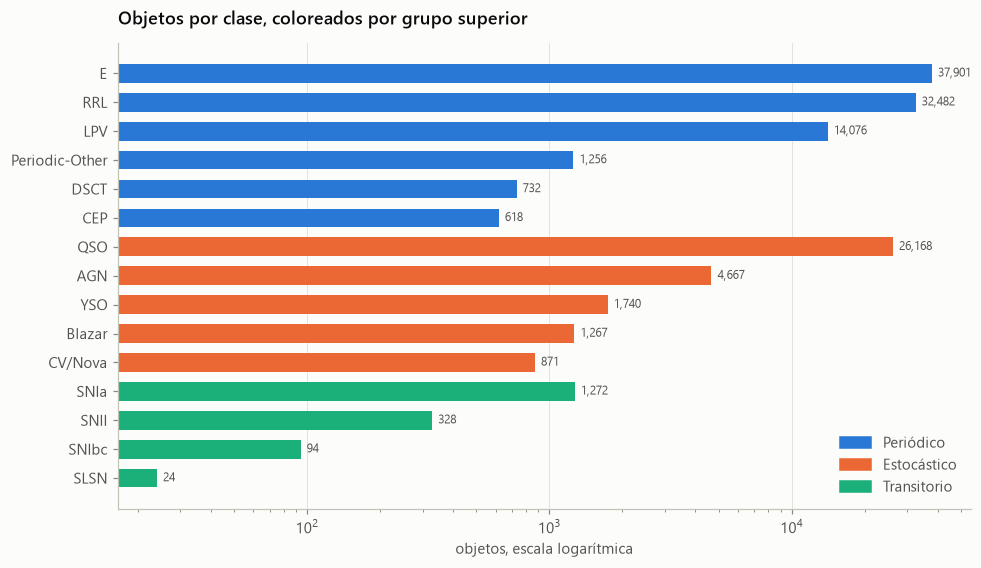

,% de los objetos
clase_superior,
Periódico,70.500
Estocástico,28.100
Transitorio,1.400


In [3]:
conteo = alerce.groupby(["clase_superior", "classALeRCE"]).size().rename("objetos").reset_index()
ORDEN = ["Periódico", "Estocástico", "Transitorio"]
COLOR = dict(zip(ORDEN, COLORES[:3]))
conteo["orden"] = conteo["clase_superior"].map({g: i for i, g in enumerate(ORDEN)})
conteo = conteo.sort_values(["orden", "objetos"], ascending=[True, False])

fig, ax = plt.subplots(figsize=(10, 5.5))
y = np.arange(len(conteo))
ax.barh(y, conteo["objetos"], color=conteo["clase_superior"].map(COLOR), height=0.65)
for i, v in enumerate(conteo["objetos"]):
    ax.annotate(f"{v:,}", (v, i), xytext=(4, 0), textcoords="offset points", va="center", fontsize=8,
                color=TINTA_SECUNDARIA)
ax.set_yticks(y, conteo["classALeRCE"])
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("objetos, escala logarítmica")
ax.set_title("Objetos por clase, coloreados por grupo superior")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=COLOR[g], label=g) for g in ORDEN], loc="lower right")
ax.grid(axis="y", visible=False)
fig.savefig(FIGURAS / "clases_alerce.png", bbox_inches="tight")
plt.show()

superior = alerce["clase_superior"].value_counts().reindex(ORDEN)
(100 * superior / superior.sum()).round(1).rename("% de los objetos").to_frame()

**Lectura.** Las clases están muy desbalanceadas. Las estrellas eclipsantes (E) y las RR Lyrae suman más de la mitad de los objetos, mientras las supernovas superluminosas (SLSN) son solo 24. En el nivel superior, los transitorios son apenas el 1,4%. Por eso la exactitud simple es una mala métrica: un modelo que nunca predice transitorios igual acertaría más del 98% de las veces. El notebook 02 usa el F1 macro, que promedia el desempeño de cada clase por igual.

## 3. Valores faltantes

In [4]:
faltantes = alerce[variables].isna().mean().sort_values(ascending=False)
print(f"Objetos con al menos un valor faltante: {alerce[variables].isna().any(axis=1).mean():.0%}")
print(f"Objetos completos: {(~alerce[variables].isna().any(axis=1)).sum():,}")
(100 * faltantes.head(10)).round(1).rename("% faltante").to_frame()

Objetos con al menos un valor faltante: 30%
Objetos completos: 86,720


,% faltante
g-r_ml,23.800
r-W3,22.500
r-W2,22.400
ExcessVar_2,16.400
MHAOV_Period_2,16.400
Pvar_2,16.400
g-W3,14.400
g-W2,14.400
g-r_max_corr,9.500
g-r_mean_corr,9.500


Los faltantes no son errores. Hay dos causas:

- **Cruce con WISE.** Los colores infrarrojos solo existen si el objeto tiene contraparte en ese catálogo.
- **Pocas observaciones en una banda.** Varias características requieren un mínimo de detecciones en la banda g (sufijo 1) o r (sufijo 2).

Descartar los objetos con algún faltante, como hacía la tesis original, eliminaría una parte grande de la muestra y además sesgaría las clases, porque los faltantes no se reparten al azar entre ellas.

In [5]:
completos_por_clase = alerce.assign(completo=~alerce[variables].isna().any(axis=1)).groupby("clase_superior")["completo"].mean()
(100 * completos_por_clase.reindex(ORDEN)).round(1).rename("% de objetos sin faltantes").to_frame()

,% de objetos sin faltantes
clase_superior,
Periódico,72.800
Estocástico,66.600
Transitorio,12.300


**Lectura.** Solo el 12% de los transitorios está completo, frente a 73% de los periódicos. Eliminar las filas incompletas borraría casi 9 de cada 10 transitorios. El modelo aprendería de un conjunto donde la clase más rara prácticamente no existe.

**Decisión.** Los faltantes se imputan con la media. En los modelos por lotes, la media se calcula con los datos de entrenamiento. En los modelos en línea se usa un imputador que actualiza su estadística a medida que llegan los datos, sin mirar el futuro.

## 4. Separación entre grupos

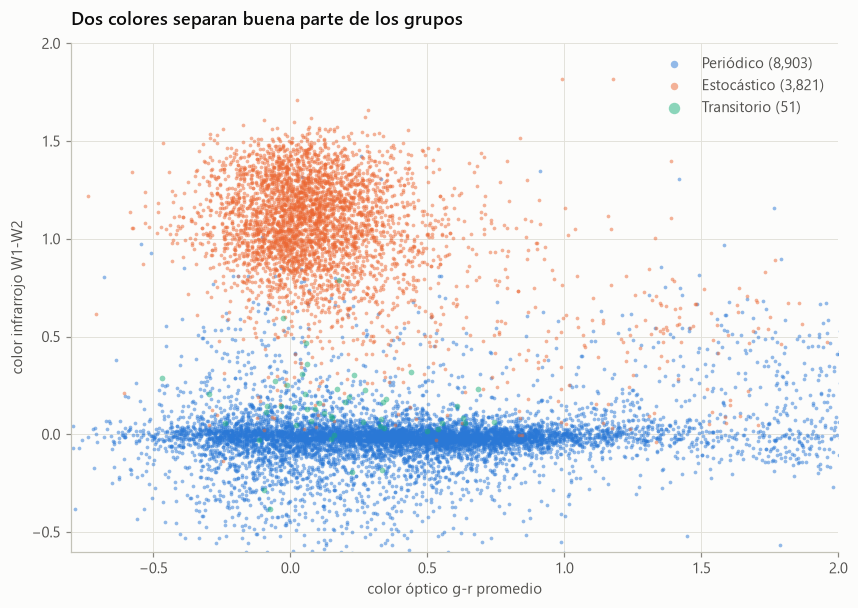

In [6]:
muestra = alerce.sample(15_000, random_state=0)
fig, ax = plt.subplots(figsize=(9, 6))
for grupo in ["Periódico", "Estocástico", "Transitorio"]:
    puntos = muestra[muestra["clase_superior"] == grupo].dropna(subset=["g-r_mean", "W1-W2"])
    ax.scatter(puntos["g-r_mean"], puntos["W1-W2"], s=6 if grupo != "Transitorio" else 14, alpha=0.5,
               color=COLOR[grupo], linewidths=0, label=f"{grupo} ({len(puntos):,})")
ax.set_xlim(-0.8, 2.0)
ax.set_ylim(-0.6, 2.0)
ax.set_xlabel("color óptico g-r promedio")
ax.set_ylabel("color infrarrojo W1-W2")
ax.set_title("Dos colores separan buena parte de los grupos")
ax.legend(loc="upper right", markerscale=2)
plt.show()

Los objetos estocásticos, sobre todo cuásares y núcleos activos, se concentran arriba: son rojos en el infrarrojo. Las estrellas periódicas quedan abajo, cerca de cero. Los pocos transitorios que tienen ambos colores aparecen mezclados con los otros grupos, y la mayoría ni siquiera se puede dibujar porque le falta el color infrarrojo. Por eso los transitorios son la clase más difícil.

## 5. Diferencias con la tesis original

| Aspecto | Tesis original | Esta versión |
|---|---|---|
| Datos | Conjunto de un desafío de clasificación, 38.702 objetos | Conjunto etiquetado publicado, 123.496 objetos |
| Faltantes | Se eliminaban las filas incompletas y quedaba un cuarto de la muestra | Imputación por la media, sin mirar datos futuros |
| Variables | Incluía el identificador del objeto como predictor | Solo características físicas |
| Jerarquía | Las estrellas LPV se agrupaban como estocásticas | Jerarquía oficial de ALeRCE, con LPV como periódicas |
| Métrica | Exactitud | F1 macro, adecuada para clases desbalanceadas |